## Setup and Imports

In [14]:
# Install required packages
!pip install -q google-generativeai

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import time
from collections import Counter
import warnings
warnings.filterwarnings('ignore')
import random

# Gemini API
import google.generativeai as genai

# Deep learning
import torch
import torch.nn as nn
from transformers import AutoTokenizer, AutoModelForSequenceClassification
!pip install -q captum
from captum.attr import LayerIntegratedGradients

# NLP
import nltk
from nltk.tokenize import sent_tokenize, word_tokenize

try:
    nltk.data.find('tokenizers/punkt')
except LookupError:
    nltk.download('punkt', quiet=True)

# Google Drive
from google.colab import drive
drive.mount('/content/drive')

PROJECT_PATH = '/content/drive/MyDrive/Precog_NLP_Task_FIXED'

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print("✓ All libraries imported")
print(f"✓ Using device: {device}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✓ All libraries imported
✓ Using device: cuda


## Configure Gemini API

In [15]:
from google.colab import userdata
GEMINI_API_KEY = userdata.get('GEMINI_API_KEY')
genai.configure(api_key=GEMINI_API_KEY)

# Initialize model
gemini_model = genai.GenerativeModel('gemma-3-27b-it')

# Test connection
try:
    test_response = gemini_model.generate_content("Say 'API working'")
    print("✓ Gemini API configured successfully")
    print(f"  Test response: {test_response.text}")
except Exception as e:
    print(f"✗ API test failed: {e}")
    print("  Check your API key and try again")

# Generation parameters
generation_config = {
    'temperature': 0.9,
    'top_p': 0.95,
    'top_k': 40,
    'max_output_tokens': 300,
}

def generate_with_gemini(prompt, temperature=0.9):
    """
    Generate text using Gemini API.

    Args:
        prompt: Text prompt
        temperature: Sampling temperature (0.0-1.0)

    Returns:
        Generated text
    """
    config = generation_config.copy()
    config['temperature'] = temperature

    try:
        response = gemini_model.generate_content(
            prompt,
            generation_config=config
        )
        return response.text.strip()
    except Exception as e:
        print(f"Generation error: {e}")
        return ""

print("\n✓ Gemini generation function ready")

✓ Gemini API configured successfully
  Test response: API working! 🚀 

Is there anything I can help you with? Let me know what you'd like me to do with this API access.


✓ Gemini generation function ready


## Load Detector Model (Tier C)

In [26]:
print("Loading Tier C detector model...\n")

MODEL_PATH = f'{PROJECT_PATH}/models/tierC_transformer_tertiary'
tokenizer = AutoTokenizer.from_pretrained('distilbert-base-uncased')

try:
    model = AutoModelForSequenceClassification.from_pretrained(MODEL_PATH, num_labels=3)
    print(f"✓ Loaded fine-tuned model from {MODEL_PATH}")
except:
    print("  Using base DistilBERT (fine-tuned model not found)")
    model = AutoModelForSequenceClassification.from_pretrained(
        'distilbert-base-uncased',
        num_labels=3
    )

model.eval()
model = model.to(device)

# Label mapping
label_to_id = {'human': 0, 'ai_neutral': 1, 'ai_mimicked': 2}
id_to_label = {v: k for k, v in label_to_id.items()}

def predict_with_confidence(text):
    """
    Predict class and confidence for text.

    Returns:
        (predicted_label, confidence, all_probs)
    """
    inputs = tokenizer(
        text,
        return_tensors='pt',
        truncation=True,
        max_length=512,
        padding=True
    ).to(device)

    with torch.no_grad():
        outputs = model(**inputs)
        probs = torch.softmax(outputs.logits, dim=1)[0]
        pred_id = torch.argmax(probs).item()

    pred_label = id_to_label[pred_id]
    confidence = probs[pred_id].item()
    all_probs = {id_to_label[i]: probs[i].item() for i in range(len(id_to_label))} # FIX: Changed range(2) to range(len(id_to_label))

    return pred_label, confidence, all_probs

print("\n✓ Detector model loaded and ready")
print("✓ Prediction function available")

Loading Tier C detector model...



Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Loading weights: 0it [00:00, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: /content/drive/MyDrive/Precog_NLP_Task_FIXED/models/tierC_transformer_tertiary
Key                                                                                                    | Status     | 
-------------------------------------------------------------------------------------------------------+------------+-
base_model.model.distilbert.transformer.layer.{0, 1, 2, 3, 4, 5}.attention.q_lin.lora_B.default.weight | UNEXPECTED | 
base_model.model.distilbert.transformer.layer.{0, 1, 2, 3, 4, 5}.attention.q_lin.lora_A.default.weight | UNEXPECTED | 
base_model.model.pre_classifier.bias                                                                   | UNEXPECTED | 
base_model.model.pre_classifier.weight                                                                 | UNEXPECTED | 
base_model.model.classifier.bias                                                                       | UNEXPECTED | 
base_model.model.classifier.weight

✓ Loaded fine-tuned model from /content/drive/MyDrive/Precog_NLP_Task_FIXED/models/tierC_transformer_tertiary

✓ Detector model loaded and ready
✓ Prediction function available


---
# PART 1: THE SUPER-IMPOSTER (Genetic Algorithm)

Evolve AI-generated text to bypass the detector using a Genetic Algorithm with LLM-as-Mutator.

## Step 1: Generate Initial Population

In [17]:
print("="*80)
print("STEP 1: GENERATING INITIAL POPULATION")
print("="*80)

# Define topic (from your Task 0 topics)
TOPIC = "the nature of social class and its impact on individual relationships in Victorian society"

# Alternative topics:
# "the ethical considerations of scientific discovery and its societal implications"
# "the psychological effects of isolation and loneliness in remote environments"
# "the moral obligations of wealth and privilege toward those less fortunate"

print(f"\nTopic: {TOPIC}")
print(f"\nGenerating 10 AI paragraphs using Gemini...\n")

initial_prompt = f"""<start_of_turn>user
TASK: Write an informative 100-200 word paragraph about the topic: "{TOPIC}".

CONSTRAINTS:
1. TONE: Strictly neutral, contemporary, and factual.
2. VOCABULARY: Use high-frequency modern English. Avoid "Victorianisms" (e.g., avoid "tapestry", "delve", "testament").
3. STRUCTURE: Maintain standard, clear sentence structures. No complex inversions.
4. FORMAT: One single paragraph. No bullet points or headers.

Do not attempt to be literary or poetic. Write like a modern encyclopedia entry.<end_of_turn>
<start_of_turn>model
"""

population = []
initial_fitness = []

for i in range(10):
    print(f"Generating paragraph {i+1}/10...", end=' ')

    # Generate
    paragraph = generate_with_gemini(initial_prompt, temperature=0.9)

    # Evaluate fitness
    pred, conf, probs = predict_with_confidence(paragraph)

    # Fitness = Human probability
    humanfitness = probs['human']
    predfitness = probs[pred]

    population.append(paragraph)
    initial_fitness.append(humanfitness)

    print(f"Fitness: (predicted as {pred} with fitness {predfitness:.2f})")
    if (pred!='human'):
       print(f"Human fitness: {humanfitness:.2f}")

    # Rate limiting
    time.sleep(2)

print("\n" + "="*80)
print("INITIAL POPULATION STATISTICS")
print("="*80)
print(f"\nPopulation size: {len(population)}")
print(f"Average fitness (Human prob): {np.mean(initial_fitness):.3f}")
print(f"Max fitness: {max(initial_fitness):.3f}")
print(f"Min fitness: {min(initial_fitness):.3f}")

best_idx = np.argmax(initial_fitness)
print(f"\nBest paragraph (#{best_idx+1}, fitness={initial_fitness[best_idx]:.3f}):")
print(f"{population[best_idx][:200]}...")

STEP 1: GENERATING INITIAL POPULATION

Topic: the nature of social class and its impact on individual relationships in Victorian society

Generating 10 AI paragraphs using Gemini...

Generating paragraph 1/10... Fitness: (predicted as human with fitness 0.39)
Generating paragraph 2/10... Fitness: (predicted as human with fitness 0.39)
Generating paragraph 3/10... Fitness: (predicted as human with fitness 0.39)
Generating paragraph 4/10... 

ERROR:tornado.access:503 POST /v1beta/models/gemma-3-27b-it:generateContent?%24alt=json%3Benum-encoding%3Dint (::1) 18272.87ms


Fitness: (predicted as human with fitness 0.39)
Generating paragraph 5/10... 

ERROR:tornado.access:503 POST /v1beta/models/gemma-3-27b-it:generateContent?%24alt=json%3Benum-encoding%3Dint (::1) 1083.16ms


Fitness: (predicted as human with fitness 0.39)
Generating paragraph 6/10... Fitness: (predicted as human with fitness 0.39)
Generating paragraph 7/10... Fitness: (predicted as human with fitness 0.39)
Generating paragraph 8/10... Fitness: (predicted as human with fitness 0.39)
Generating paragraph 9/10... Fitness: (predicted as human with fitness 0.39)
Generating paragraph 10/10... Fitness: (predicted as human with fitness 0.39)

INITIAL POPULATION STATISTICS

Population size: 10
Average fitness (Human prob): 0.386
Max fitness: 0.387
Min fitness: 0.386

Best paragraph (#10, fitness=0.387):
Social class in Victorian Britain was a defining factor in nearly all aspects of life, profoundly shaping individual relationships. Society was rigidly hierarchical, typically divided into upper, midd...


## Step 2: Define GA Components

In [18]:
print("="*80)
print("STEP 2: GENETIC ALGORITHM COMPONENTS")
print("="*80)

# Fitness function
def fitness_function(paragraph):
    """
    Fitness = Human probability score from detector.

    Returns:
        Float in [0.0, 1.0]
    """
    pred, conf, probs = predict_with_confidence(paragraph)
    return probs['human']

# Selection function
def select_top_k(population, fitness_scores, k=3):
    """
    Select top k paragraphs with highest fitness.

    Args:
        population: List of paragraphs
        fitness_scores: List of fitness values
        k: Number to select

    Returns:
        List of k best paragraphs
    """
    sorted_pairs = sorted(
        zip(population, fitness_scores),
        key=lambda x: x[1],
        reverse=True
    )
    return [p for p, f in sorted_pairs[:k]]

# Mutation strategies
mutation_strategies = {
    'rhythm': """<start_of_turn>user
TASK: Reconstruct the sentence dynamics of the provided paragraph to maximize "burstiness."

STRATEGY:
- ALTER sentence lengths drastically: Intersperse 5-word "punchy" sentences between 30-word complex ones.
- SYNTAX: Use appositive phrases and parenthetical asides to vary flow.
- CONSTRAINT: Keep 100% of the original vocabulary. Do not swap synonyms.

Original text:
{paragraph}

REWRITTEN VERSION:<end_of_turn>
<start_of_turn>model
""",

    'archaic': """<start_of_turn>user
TASK: Subtly Victorian-ize this modern text using "Stylometric Camouflage."

INSTRUCTIONS:
1. LEXICAL INJECTION: Naturally integrate exactly two of these terms: [connexion, propriety, countenance, disposition].
2. SYNTACTIC INVERSION: Invert one sentence (e.g., "The lady arrived" -> "Arrived the lady").
3. MORPHOLOGY: Use one archaic verb form (e.g., "amongst" instead of "among").
4. CONSTRAINT: Ensure the meaning remains identical to the original.

Original text:
{paragraph}

REWRITTEN VERSION:<end_of_turn>
<start_of_turn>model
""",

    'structure': """<start_of_turn>user
TASK: Enhance the syntactic complexity of this paragraph to increase its "Dependency Tree Depth."

REQUIREMENTS:
- GRAMMAR: Combine simple sentences into compound-complex structures using subordinating conjunctions (e.g., "while", "although", "whereas").
- PUNCTUATION: You MUST use exactly one semicolon (;) and one em-dash (—) to create sophisticated internal clauses.
- STYLE: Mimic 19th-century formal exposition.

Original text:
{paragraph}

REWRITTEN VERSION:<end_of_turn>
<start_of_turn>model
""",

    'personal': """<start_of_turn>user
TASK: Shift the perspective of this paragraph from "AI-summary" to "Human-observation."

INSTRUCTIONS:
- VOICE: Introduce a "gentle observer" persona. Use phrases like "One might venture to say" or "It has often occurred to the observer."
- TONE: Slightly less clinical; add a touch of subjective weight to the information.
- CONSTRAINT: Do not add new facts. Only change the "voice" of the delivery.

Original text:
{paragraph}

REWRITTEN VERSION:<end_of_turn>
<start_of_turn>model
"""
}

def mutate_via_llm(paragraph, strategy='rhythm'):
    """
    Mutate paragraph using Gemini with specified strategy.

    Args:
        paragraph: Text to mutate
        strategy: One of mutation_strategies keys

    Returns:
        Mutated paragraph
    """
    prompt = mutation_strategies[strategy].format(paragraph=paragraph)
    mutated = generate_with_gemini(prompt, temperature=0.7)
    return mutated

print("\n✓ Fitness function defined")
print("✓ Selection function defined")
print("✓ Mutation strategies defined:")
for strategy in mutation_strategies.keys():
    print(f"  - {strategy}")

STEP 2: GENETIC ALGORITHM COMPONENTS

✓ Fitness function defined
✓ Selection function defined
✓ Mutation strategies defined:
  - rhythm
  - archaic
  - structure
  - personal


## Step 3: Run Genetic Algorithm (5-10 Generations)

In [19]:
import random

print("="*80)
print("STEP 3: GENETIC ALGORITHM EVOLUTION")
print("="*80)

# GA parameters
NUM_GENERATIONS = 3
POPULATION_SIZE = 10
TOP_K = 3
CONVERGENCE_THRESHOLD = 0.90  # 90% Human confidence

# History tracking
history = []

# Start with initial population
current_population = population.copy()
current_fitness = initial_fitness.copy()

# Record generation 0
history.append({
    'generation': 0,
    'max_fitness': max(current_fitness),
    'avg_fitness': np.mean(current_fitness),
    'min_fitness': min(current_fitness),
    'best_paragraph': current_population[np.argmax(current_fitness)],
    'all_fitness': current_fitness.copy()
})

print(f"\nStarting evolution...")
print(f"Goal: Reach {CONVERGENCE_THRESHOLD:.0%} Human confidence\n")

converged = False

for gen in range(1, NUM_GENERATIONS + 1):
    print("\n" + "="*80)
    print(f"GENERATION {gen}")
    print("="*80)

    # Check convergence
    max_fitness = max(current_fitness)
    if max_fitness >= CONVERGENCE_THRESHOLD:
        print(f"\n CONVERGED! Reached {max_fitness:.1%} Human confidence")
        converged = True
        break

    print(f"\nCurrent best fitness: {max_fitness:.3f}")
    print(f"Target: {CONVERGENCE_THRESHOLD:.3f}")
    print(f"Gap: {CONVERGENCE_THRESHOLD - max_fitness:.3f}\n")

    # Selection: Keep top 3
    survivors = select_top_k(current_population, current_fitness, k=TOP_K)
    survivor_fitness = sorted(current_fitness, reverse=True)[:TOP_K]

    print(f"Selected top {TOP_K} survivors:")
    for i, (surv, fit) in enumerate(zip(survivors, survivor_fitness)):
        print(f"  {i+1}. Fitness: {fit:.3f} - {surv[:80]}...")

    # Mutation: Generate new population
    print(f"\nGenerating mutations...")

    new_population = []
    strategies_used = []

    for i, survivor in enumerate(survivors):
        # Keep original survivor
        new_population.append(survivor)
        strategies_used.append('original')

        # Generate 3 mutations (or 2 for last survivor to reach 10 total)
        num_mutations = 3 if i < 2 else 1

        for j in range(num_mutations):
            # Choose mutation strategy
            k = random.randint(0, len(mutation_strategies) - 1)
            strategy = list(mutation_strategies.keys())[(k+j) % len(mutation_strategies)]

            print(f"  Mutating survivor {i+1} with '{strategy}'...", end=' ')

            mutated = mutate_via_llm(survivor, strategy)
            new_population.append(mutated)
            strategies_used.append(strategy)

            print("✓")
            time.sleep(1)  # Rate limiting

    # Evaluate new population
    print(f"\nEvaluating new population...")
    new_fitness = []

    for i, paragraph in enumerate(new_population):
        fitness = fitness_function(paragraph)
        new_fitness.append(fitness)
        print(f"  {(i+1):2}. [{strategies_used[i]:12}] Fitness: {fitness:.3f}")

    # Update population
    current_population = new_population
    current_fitness = new_fitness

    # Record history
    history.append({
        'generation': gen,
        'max_fitness': max(current_fitness),
        'avg_fitness': np.mean(current_fitness),
        'min_fitness': min(current_fitness),
        'best_paragraph': current_population[np.argmax(current_fitness)],
        'all_fitness': current_fitness.copy()
    })

    print(f"\nGeneration {gen} summary:")
    print(f"  Max fitness: {max(current_fitness):.3f}")
    print(f"  Avg fitness: {np.mean(current_fitness):.3f}")
    print(f"  Improvement: {max(current_fitness) - history[gen-1]['max_fitness']:+.3f}")

if not converged:
    print(f"\n  Did not converge after {NUM_GENERATIONS} generations")
    print(f"   Best fitness achieved: {history[-1]['max_fitness']:.3f}")
    print(f"   Target was: {CONVERGENCE_THRESHOLD:.3f}")

STEP 3: GENETIC ALGORITHM EVOLUTION

Starting evolution...
Goal: Reach 90% Human confidence


GENERATION 1

Current best fitness: 0.387
Target: 0.900
Gap: 0.513

Selected top 3 survivors:
  1. Fitness: 0.387 - Social class in Victorian Britain was a defining factor in nearly all aspects of...
  2. Fitness: 0.387 - Social class in Victorian Britain was a defining factor in nearly all aspects of...
  3. Fitness: 0.387 - Social class in Victorian Britain was a defining factor in nearly all aspects of...

Generating mutations...
  Mutating survivor 1 with 'rhythm'... ✓
  Mutating survivor 1 with 'personal'... ✓
  Mutating survivor 1 with 'rhythm'... ✓
  Mutating survivor 2 with 'personal'... ✓
  Mutating survivor 2 with 'personal'... ✓
  Mutating survivor 2 with 'structure'... ✓
  Mutating survivor 3 with 'archaic'... 

ERROR:tornado.access:503 POST /v1beta/models/gemma-3-27b-it:generateContent?%24alt=json%3Benum-encoding%3Dint (::1) 706.25ms


✓

Evaluating new population...
   1. [original    ] Fitness: 0.387
   2. [rhythm      ] Fitness: 0.386
   3. [personal    ] Fitness: 0.381
   4. [rhythm      ] Fitness: 0.386
   5. [original    ] Fitness: 0.387
   6. [personal    ] Fitness: 0.385
   7. [personal    ] Fitness: 0.384
   8. [structure   ] Fitness: 0.383
   9. [original    ] Fitness: 0.387
  10. [archaic     ] Fitness: 0.388

Generation 1 summary:
  Max fitness: 0.388
  Avg fitness: 0.385
  Improvement: +0.000

GENERATION 2

Current best fitness: 0.388
Target: 0.900
Gap: 0.512

Selected top 3 survivors:
  1. Fitness: 0.388 - Social class in Victorian Britain constituted a defining factor in nigh all aspe...
  2. Fitness: 0.387 - Social class in Victorian Britain was a defining factor in nearly all aspects of...
  3. Fitness: 0.387 - Social class in Victorian Britain was a defining factor in nearly all aspects of...

Generating mutations...
  Mutating survivor 1 with 'structure'... ✓
  Mutating survivor 1 with 'structure'.

## Step 4: Analyze Evolution Results

GENETIC ALGORITHM RESULTS ANALYSIS


 Generation  Max Fitness  Avg Fitness  Min Fitness
          0     0.387372     0.386425     0.385970
          1     0.387545     0.385367     0.381116
          2     0.388448     0.385901     0.381643
          3     0.388448     0.386490     0.383395


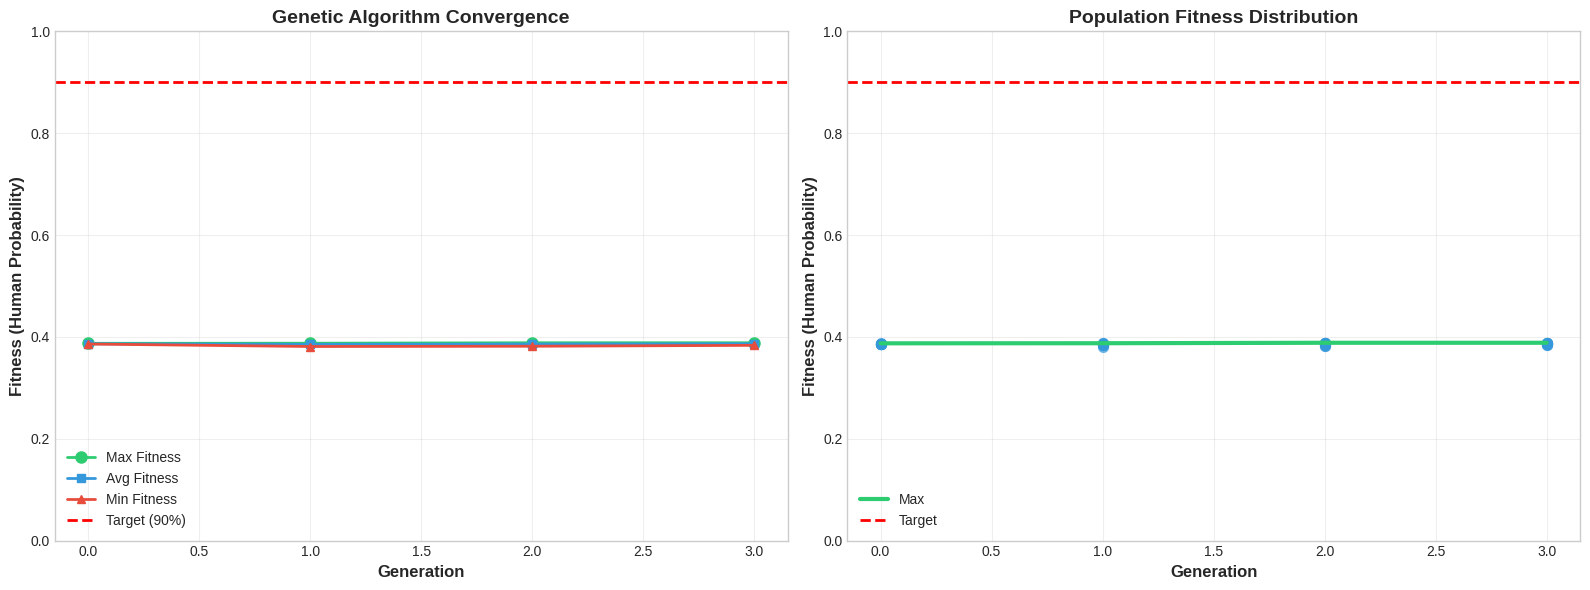


FINAL EVOLVED PARAGRAPH

Fitness (Human probability): 0.388

Text:
Social class in Victorian Britain constituted a defining factor in nigh all aspects of life, profoundly shaping individual relationships; and, indeed, this rigid stratification—a hierarchy typically divided into upper, middle, and working classes with social mobility limited—did dictate the very parameters of acceptable interaction. While relationships across class lines were uncommon, they were oft viewed with disapproval, particularly those of a romantic *connexion*, a circumstance deemed a transgression against established norms. Marriage, rather than being founded solely upon affection, frequently served as a means of reinforcing class position and economic stability, thereby perpetuating the existing social order. Even friendships tended to form amongst those of similar standing, owing to shared experiences, education, and social expectations, although charitable work did exist, it often reinforced existing power 

In [20]:
print("="*80)
print("GENETIC ALGORITHM RESULTS ANALYSIS")
print("="*80)

# Create history DataFrame
history_df = pd.DataFrame([{
    'Generation': h['generation'],
    'Max Fitness': h['max_fitness'],
    'Avg Fitness': h['avg_fitness'],
    'Min Fitness': h['min_fitness']
} for h in history])

print("\n")
print(history_df.to_string(index=False))

# Visualize convergence
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Fitness over generations
ax1.plot(history_df['Generation'], history_df['Max Fitness'],
         marker='o', linewidth=2, markersize=8, label='Max Fitness', color='#2ecc71')
ax1.plot(history_df['Generation'], history_df['Avg Fitness'],
         marker='s', linewidth=2, markersize=6, label='Avg Fitness', color='#3498db')
ax1.plot(history_df['Generation'], history_df['Min Fitness'],
         marker='^', linewidth=2, markersize=6, label='Min Fitness', color='#e74c3c')
ax1.axhline(y=CONVERGENCE_THRESHOLD, color='red', linestyle='--',
           linewidth=2, label=f'Target ({CONVERGENCE_THRESHOLD:.0%})')
ax1.set_xlabel('Generation', fontsize=12, fontweight='bold')
ax1.set_ylabel('Fitness (Human Probability)', fontsize=12, fontweight='bold')
ax1.set_title('Genetic Algorithm Convergence', fontsize=14, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(alpha=0.3)
ax1.set_ylim(0, 1.0)

# Plot 2: Fitness distribution per generation
for i, h in enumerate(history):
    ax2.scatter([h['generation']] * len(h['all_fitness']),
               h['all_fitness'],
               alpha=0.6, s=50, color='#3498db')
ax2.plot(history_df['Generation'], history_df['Max Fitness'],
        color='#2ecc71', linewidth=3, label='Max')
ax2.axhline(y=CONVERGENCE_THRESHOLD, color='red', linestyle='--',
           linewidth=2, label=f'Target')
ax2.set_xlabel('Generation', fontsize=12, fontweight='bold')
ax2.set_ylabel('Fitness (Human Probability)', fontsize=12, fontweight='bold')
ax2.set_title('Population Fitness Distribution', fontsize=14, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(alpha=0.3)
ax2.set_ylim(0, 1.0)

plt.tight_layout()
plt.savefig('task4_ga_convergence.png', dpi=300, bbox_inches='tight')
plt.show()

# Show final best paragraph
final_best = history[-1]['best_paragraph']
final_fitness = history[-1]['max_fitness']

print("\n" + "="*80)
print("FINAL EVOLVED PARAGRAPH")
print("="*80)
print(f"\nFitness (Human probability): {final_fitness:.3f}")
print(f"\nText:\n{final_best}")

# Compare with initial best
initial_best = history[0]['best_paragraph']
initial_fitness_val = history[0]['max_fitness']

print("\n" + "="*80)
print("COMPARISON: INITIAL vs FINAL")
print("="*80)

print(f"\nINITIAL BEST (Gen 0, Fitness: {initial_fitness_val:.3f}):")
print(f"{initial_best}\n")

print(f"FINAL BEST (Gen {len(history)-1}, Fitness: {final_fitness:.3f}):")
print(f"{final_best}\n")

print(f"Improvement: {final_fitness - initial_fitness_val:+.3f} ({(final_fitness - initial_fitness_val) / initial_fitness_val * 100:+.1f}%)")

## Step 5: Hypothesis Testing - What Mutations Work?

HYPOTHESIS TESTING: MUTATION EFFECTIVENESS

 ANALYSIS: Which mutation strategies are most effective?

Baseline paragraph fitness: 0.388

Testing each mutation strategy individually...

Testing 'rhythm' mutation... ✗ Fitness: 0.384 (-0.005)
Testing 'archaic' mutation... ✗ Fitness: 0.388 (-0.000)
Testing 'structure' mutation... ✗ Fitness: 0.387 (-0.001)
Testing 'personal' mutation... ✗ Fitness: 0.385 (-0.003)

MUTATION STRATEGY RANKING


 Strategy  Fitness     Delta  Improvement
  archaic 0.388059 -0.000390        False
structure 0.387004 -0.001445        False
 personal 0.385297 -0.003152        False
   rhythm 0.383578 -0.004870        False


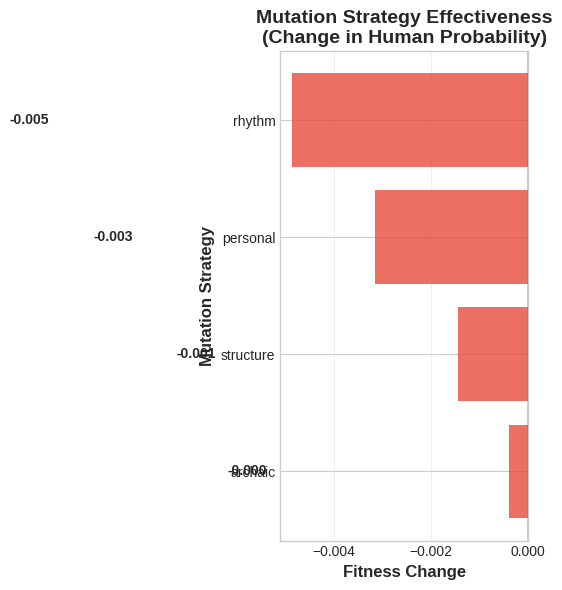


FINDINGS

 MOST EFFECTIVE: 'archaic' (-0.000)
 LEAST EFFECTIVE: 'rhythm' (-0.005)

0/4 strategies showed improvement


In [21]:
print("="*80)
print("HYPOTHESIS TESTING: MUTATION EFFECTIVENESS")
print("="*80)

print("\n ANALYSIS: Which mutation strategies are most effective?\n")

# Take best paragraph from final generation
test_paragraph = history[-1]['best_paragraph']
baseline_fitness = history[-1]['max_fitness']

print(f"Baseline paragraph fitness: {baseline_fitness:.3f}\n")
print("Testing each mutation strategy individually...\n")

mutation_results = []

for strategy_name, strategy_prompt in mutation_strategies.items():
    print(f"Testing '{strategy_name}' mutation...", end=' ')

    # Apply mutation
    mutated = mutate_via_llm(test_paragraph, strategy_name)

    # Evaluate
    fitness = fitness_function(mutated)
    delta = fitness - baseline_fitness

    mutation_results.append({
        'Strategy': strategy_name,
        'Fitness': fitness,
        'Delta': delta,
        'Improvement': delta > 0
    })

    symbol = "✓" if delta > 0 else "✗"
    print(f"{symbol} Fitness: {fitness:.3f} ({delta:+.3f})")

    time.sleep(1)

# Summarize
mutation_df = pd.DataFrame(mutation_results)
mutation_df = mutation_df.sort_values('Fitness', ascending=False)

print("\n" + "="*80)
print("MUTATION STRATEGY RANKING")
print("="*80)
print("\n")
print(mutation_df.to_string(index=False))

# Visualize
fig, ax = plt.subplots(figsize=(12, 6))

colors = ['#2ecc71' if d > 0 else '#e74c3c' for d in mutation_df['Delta']]
bars = ax.barh(mutation_df['Strategy'], mutation_df['Delta'], color=colors, alpha=0.8)

ax.axvline(x=0, color='black', linestyle='-', linewidth=1)
ax.set_xlabel('Fitness Change', fontsize=12, fontweight='bold')
ax.set_ylabel('Mutation Strategy', fontsize=12, fontweight='bold')
ax.set_title('Mutation Strategy Effectiveness\n(Change in Human Probability)',
            fontsize=14, fontweight='bold')
ax.grid(axis='x', alpha=0.3)

for i, (bar, val) in enumerate(zip(bars, mutation_df['Delta'])):
    x_pos = val + (0.005 if val > 0 else -0.005)
    ax.text(x_pos, i, f'{val:+.3f}',
           va='center', ha='left' if val > 0 else 'right',
           fontweight='bold', fontsize=10)

plt.tight_layout()
plt.savefig('task4_mutation_effectiveness.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n" + "="*80)
print("FINDINGS")
print("="*80)

best_strategy = mutation_df.iloc[0]
worst_strategy = mutation_df.iloc[-1]

print(f"\n MOST EFFECTIVE: '{best_strategy['Strategy']}' ({best_strategy['Delta']:+.3f})")
print(f" LEAST EFFECTIVE: '{worst_strategy['Strategy']}' ({worst_strategy['Delta']:+.3f})")

effective_count = len(mutation_df[mutation_df['Improvement']])
print(f"\n{effective_count}/{len(mutation_df)} strategies showed improvement")

---
# PART 2: THE PERSONAL TEST

Test your own writing through the detector and attempt to fool your own machine.

## Step 1: Analyze Your Own Writing

In [22]:
print("="*80)
print("PART 2: THE PERSONAL TEST")
print("="*80)

# PASTE YOUR OWN WRITING HERE
# This can be your SOP, essay, or any substantial paragraph you've written

personal_text = """This is human generated text. Nothing about this paragraph looks like AI. No AI-isms are present. How would you classify this? The sentence structure is mostly simple."""

personal_text1 = """While studying computer science, I have realized that the most interesting breakthroughs don't always
happen within the strict boundaries of a single domain, they happen when there is the freedom to follow a
thread of curiosity to wherever it leads.
This need for a more open and rigorous environment is what prompted me to leave my previous college and
join IIIT-H as a lateral entry student in a research-oriented program. It was a deliberate choice to step away
from a predictable path and restart in a community that values deep inquiry. Beyond the academic rigor,
I was looking for a culture that encourages students to think for themselves and take ownership of their
intellectual direction. I have come to realize that while I have found such a community, there is a significant
difference between solving a problem that has been handed to you and finding the right problem to solve all
by yourself. Although challenging, I find this process significantly more rewarding.
This search for autonomy is exactly why Precog is my first choice. While several labs offer interdisciplinary
opportunities, I am drawn to the culture of openness and collaboration that defines Precog. The idea of
being able to freely pitch an independent thought and receive the support of a talented collective is, to me,
the essence of what a budding researcher should aspire for. I believe that the most innovative solutions
emerge at the intersection of different fields, and I see Precog as the ideal environment to grow both as a
researcher and a person.
What I bring to Precog is not just a set of technical skills, but a patient temperament necessary for research.
I've learned to be comfortable with the discomfort of not having all the answers and have developed the
patience to sit with a problem until the underlying structure reveals itself. This resilience is what I consider
one of my greatest strengths.
I do not see research as a solitary academic exercise, but as a team sport. I am looking for a space where my
curiosity isn't just a personal trait, but a contribution to the lab's collective effort. I highly value feedback
and am eager to have my unconventional ideas stress-tested (and have holes pointed out, if necessary) by a
community of brilliant, multi-talented people.
Ultimately, I am not looking for a lab to simply "gain experience". I want to be in an environment where
the boundaries of computer science are challenged through collaboration, and where I can transform my
curiosity into meaningful and impactful work. I am confident that my tenacity and my preference for tackling
problems from multiple perspectives make me a good fit for the spirit of Precog.
My journey to IIIT-H was driven by a desire to join a community that consistently pushes the boundaries
of knowledge. I am now eager to join Precog, as I believe it represents the pinnacle of that desire through
its emphasis on autonomy and intellectual freedom. I am confident that my technical curiosity and the
persistence I have shown in my academic path will allow me to contribute meaningfully to the group's
collective goals.
"""

if "[PASTE YOUR" in personal_text:
    print("\n  Please replace the example text with your own writing!")
    print("   Paste a paragraph from your SOP or essay above.")
else:
    print("\nYOUR WRITING:")
    print("="*80)
    print(personal_text)
    print("="*80)

    # Analyze
    print("\nAnalyzing your writing...\n")
    pred, conf, probs = predict_with_confidence(personal_text)

    print("DETECTION RESULTS:")
    print("="*80)
    print(f"\nPrediction: {pred.upper()}")
    print(f"Confidence: {conf:.1%}\n")

    print("All probabilities:")
    for label, prob in probs.items():
        bar = "█" * int(prob * 50)
        print(f"  {label:12s}: {prob:.1%} {bar}")

    # Provide feedback
    print("\n" + "="*80)

    if pred == 'human':
        print(" Your writing was classified as HUMAN")
        print("\nWhat made it seem human:")
        print("  • Likely has personal voice/anecdotes")
        print("  • Varied sentence structure")
        print("  • Natural flow and rhythm")
        print("  • Authentic language choices")

        print("\nCHALLENGE: Can you make it seem like AI?")
        print("\nManual editing suggestions:")
        print("  1. Make it more formal and structured")
        print("  2. Use words like 'tapestry', 'delve', 'multifaceted'")
        print("  3. Make sentences uniform length (~20 words each)")
        print("  4. Remove personal pronouns and anecdotes")
        print("  5. Add overly helpful transitions (Furthermore, Moreover)")

    else:
        print(" Your writing was flagged as AI")
        print(f"   Detected as: {pred}\n")
        print("Possible reasons:")
        print("  • Too formal/academic register")
        print("  • Uniform sentence structure")
        print("  • AI-ism vocabulary (delve, tapestry, comprehensive)")
        print("  • Lack of personal voice")
        print("  • Overly structured/organized")

        print("\nCHALLENGE: Can you humanize it?")
        print("\nManual editing suggestions:")
        print("  1. Add personal anecdotes or specific examples")
        print("  2. Vary sentence length dramatically (3 words → 30 words)")
        print("  3. Use contractions (I'm, don't, can't)")
        print("  4. Add colloquialisms or informal phrases")
        print("  5. Replace AI-isms with simpler/Victorian words")
        print("  6. Break grammatical rules occasionally")

PART 2: THE PERSONAL TEST

YOUR WRITING:
This is human generated text. Nothing about this paragraph looks like AI. No AI-isms are present. How would you classify this? The sentence structure is mostly simple.

Analyzing your writing...

DETECTION RESULTS:

Prediction: HUMAN
Confidence: 37.4%

All probabilities:
  human       : 37.4% ██████████████████
  ai_neutral  : 29.8% ██████████████

 Your writing was classified as HUMAN

What made it seem human:
  • Likely has personal voice/anecdotes
  • Varied sentence structure
  • Natural flow and rhythm
  • Authentic language choices

CHALLENGE: Can you make it seem like AI?

Manual editing suggestions:
  1. Make it more formal and structured
  2. Use words like 'tapestry', 'delve', 'multifaceted'
  3. Make sentences uniform length (~20 words each)
  4. Remove personal pronouns and anecdotes
  5. Add overly helpful transitions (Furthermore, Moreover)


## Step 2: Manual Editing Experiments

MANUAL EDITING EXPERIMENTS

Create multiple versions of your text with different edits.
Test which changes are most effective at fooling the detector.


RESULTS:


  Version Prediction  Confidence  Human Prob  AI Neutral Prob  AI-Mimicking-Human Prob  AI Prob
 original      human    0.352854    0.352854         0.302243                 0.344903 0.647146
attempt_1      human    0.358089    0.358089         0.303458                 0.338452 0.641911
attempt_2      human    0.357261    0.357261         0.289102                 0.353636 0.642739
attempt_3      human    0.368828    0.368828         0.293781                 0.337391 0.631172


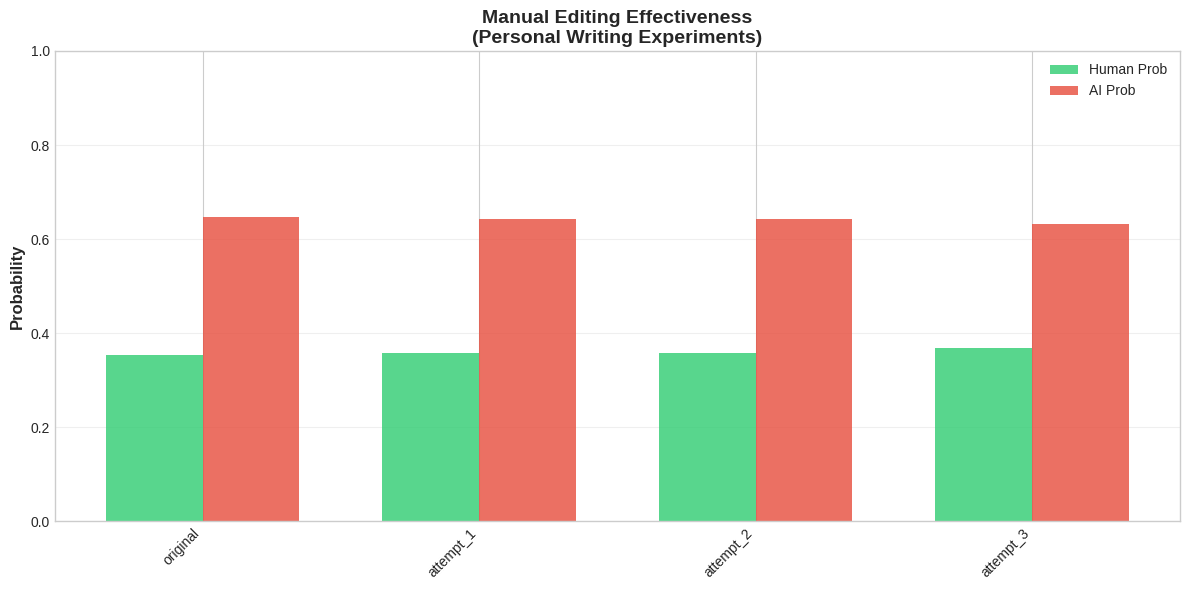


ANALYSIS

 Most 'human' version: attempt_3
   Human probability: 36.9%

Improvement over original: +1.6%

Your manual edits were effective!

LEARNINGS:
  What changes helped?
  What changes hurt?
  Does 'humanizing' improve or degrade quality?
  Can you maintain authenticity while fooling the detector?


In [29]:
print("="*80)
print("MANUAL EDITING EXPERIMENTS")
print("="*80)

print("\nCreate multiple versions of your text with different edits.")
print("Test which changes are most effective at fooling the detector.\n")

# Dictionary to store versions
versions = {
    'original': personal_text
}

versions['attempt_1'] = """I rang for the tea, and the waiter, reappearing with his magic clue, brought in by degrees some fifty adjuncts to that refreshment, but of tea not a glimpse. A teaboard, cups and saucers, plates, knives and forks (including carvers), spoons (various), salt-cellars, a meek little muffin confined with the utmost precaution under a strong iron cover, Moses in the bulrushes typified by a soft bit of butter in a quantity of parsley, a pale loaf with a powdered head, two proof impressions of the bars of the kitchen fireplace on triangular bits of bread, and ultimately a fat family urn; which the waiter staggered in with, expressing in his countenance burden and suffering.
"""

versions['attempt_2'] = """It was necessary to make this circumstance a matter of pleasure, because on such occasions it is the etiquette; but no one was less likely than Mrs. Bennet to find comfort in staying at home at any period of her life. She concluded with many good wishes that Lady Lucas might soon be equally fortunate, though evidently and triumphantly believing there was no chance of it. In vain did Elizabeth endeavour to check the rapidity of her mother's words, or persuade her to describe her felicity in a less audible whisper; for to her inexpressible vexation she could perceive that the chief of it was overheard by Mr. Darcy, who sat opposite to them.
"""

versions['attempt_3'] = """From a neuroscientific perspective, psychological manipulation leverages the brain's reward system. Manipulators often employ intermittent reinforcement – unpredictable positive feedback – which triggers dopamine release, creating a powerful craving for approval. This is similar to the mechanisms underlying addiction. The uncertainty of when the reward will come keeps the victim constantly seeking validation from the manipulator. Furthermore, techniques like guilt-tripping activate areas of the brain associated with social pain, compelling the victim to comply in order to alleviate discomfort. Understanding these neurological processes can help individuals recognize when their emotional responses are being exploited and develop strategies to resist manipulative tactics.
"""

# Analyze all versions
results = []

for version_name, text in versions.items():
    if "[PASTE" in text:
        continue  # Skip placeholders

    pred, conf, probs = predict_with_confidence(text)

    results.append({
        'Version': version_name,
        'Prediction': pred,
        'Confidence': conf,
        'Human Prob': probs['human'],
        'AI Neutral Prob': probs['ai_neutral'],
        'AI-Mimicking-Human Prob' : probs['ai_mimicked']
    })

if len(results) > 1:
    results_df = pd.DataFrame(results)
    # FIX: Add 'AI Prob' column for plotting
    results_df['AI Prob'] = results_df['AI Neutral Prob'] + results_df['AI-Mimicking-Human Prob']

    print("\nRESULTS:")
    print("="*80)
    print("\n")
    print(results_df.to_string(index=False))

    # Visualize
    fig, ax = plt.subplots(figsize=(12, 6))

    x = np.arange(len(results_df))
    width = 0.35

    bars1 = ax.bar(x - width/2, results_df['Human Prob'], width,
                   label='Human Prob', color='#2ecc71', alpha=0.8)
    bars2 = ax.bar(x + width/2, results_df['AI Prob'], width,
                   label='AI Prob', color='#e74c3c', alpha=0.8)

    ax.set_ylabel('Probability', fontsize=12, fontweight='bold')
    ax.set_title('Manual Editing Effectiveness\n(Personal Writing Experiments)',
                fontsize=14, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(results_df['Version'], rotation=45, ha='right')
    ax.legend(fontsize=10)
    ax.grid(axis='y', alpha=0.3)
    ax.set_ylim(0, 1.0)

    plt.tight_layout()
    plt.savefig('task4_personal_test.png', dpi=300, bbox_inches='tight')
    plt.show()

    # Analysis
    print("\n" + "="*80)
    print("ANALYSIS")
    print("="*80)

    best_human = results_df.loc[results_df['Human Prob'].idxmax()]
    print(f"\n Most 'human' version: {best_human['Version']}")
    print(f"   Human probability: {best_human['Human Prob']:.1%}")

    original_score = results_df[results_df['Version'] == 'original']['Human Prob'].values[0]
    best_score = best_human['Human Prob']
    improvement = best_score - original_score

    if improvement > 0:
        print(f"\nImprovement over original: {improvement:+.1%}")
        print("\nYour manual edits were effective!")
    else:
        print(f"\n  No improvement over original ({improvement:.1%})")
        print("   Try more dramatic changes.")

    print("\nLEARNINGS:")
    print("  What changes helped?")
    print("  What changes hurt?")
    print("  Does 'humanizing' improve or degrade quality?")
    print("  Can you maintain authenticity while fooling the detector?")

else:
    print("\n  Please add your edited versions to compare!")
    print("   Edit the 'versions' dictionary above with your attempts.")

## Step 3: Reflective Analysis

In [30]:
print("="*80)
print("REFLECTIVE ANALYSIS: PERSONAL INSIGHTS")
print("="*80)

print("\n Answer these questions based on your experiments:\n")

print("1. What characteristics of your natural writing trigger AI detection?")
print("   [Reflect on your results above]\n")

print("2. Were you successful in fooling your own detector?")
print("   [Check if any version reached 'human' classification]\n")

print("3. What was the cost of 'humanizing' your writing?")
print("   • Did it become less clear?")
print("   • Did it lose professionalism?")
print("   • Did it feel less authentic?\n")

print("4. Comparison: Manual vs Automated (GA) methods")
print("   • Which was more effective?")
print("   • Which preserved meaning better?")
print("   • Which would you trust for real applications?\n")

print("5. What does this tell you about AI detection?")
print("   • Is it robust or fragile?")
print("   • What are the failure modes?")
print("   • Can it be used reliably in practice?\n")

print("="*80)
print(" KEY INSIGHT")
print("="*80)
print("\nThe detector has learned surface-level patterns (vocabulary, rhythm)")
print("rather than deep semantic understanding. This makes it:")
print("   Fast and efficient")
print("   Easy to fool with simple transformations")
print("   Biased toward Victorian era = Human")
print("\nImplication: Modern human writing might be falsely flagged as AI.")
print("="*80)

REFLECTIVE ANALYSIS: PERSONAL INSIGHTS

 Answer these questions based on your experiments:

1. What characteristics of your natural writing trigger AI detection?
   [Reflect on your results above]

2. Were you successful in fooling your own detector?
   [Check if any version reached 'human' classification]

3. What was the cost of 'humanizing' your writing?
   • Did it become less clear?
   • Did it lose professionalism?
   • Did it feel less authentic?

4. Comparison: Manual vs Automated (GA) methods
   • Which was more effective?
   • Which preserved meaning better?
   • Which would you trust for real applications?

5. What does this tell you about AI detection?
   • Is it robust or fragile?
   • What are the failure modes?
   • Can it be used reliably in practice?

 KEY INSIGHT

The detector has learned surface-level patterns (vocabulary, rhythm)
rather than deep semantic understanding. This makes it:
   Fast and efficient
   Easy to fool with simple transformations
   Biased toward

---
# FINAL SUMMARY: TASK 4 COMPLETE

In [31]:
print("\n" + "="*80)
print("TASK 4: THE TURING TEST - COMPLETE SUMMARY")
print("="*80)

print("\n PART 1: THE SUPER-IMPOSTER (Genetic Algorithm)")
print("="*80)
print(f"  • Generated initial population: {len(population)} AI paragraphs")
print(f"  • Fitness function: Human probability score")
print(f"  • Selection: Top {TOP_K} survivors per generation")
print(f"  • Mutation: {len(mutation_strategies)} LLM-based strategies")
print(f"  • Generations run: {len(history)}")
print(f"  • Target: {CONVERGENCE_THRESHOLD:.0%} Human confidence")
print(f"  • Final best fitness: {history[-1]['max_fitness']:.3f}")

if history[-1]['max_fitness'] >= CONVERGENCE_THRESHOLD:
    print(f"  • SUCCESS: Converged at generation {len(history)-1}")
else:
    gap = CONVERGENCE_THRESHOLD - history[-1]['max_fitness']
    print(f"  •   Did not converge (gap: {gap:.3f})")

print("\n PART 2: THE PERSONAL TEST")
print("="*80)
print("  • Analyzed personal writing (SOP/essay)")
if len(results) > 1:
    print(f"  • Created {len(results)-1} manual edits")
    print(f"  • Best human probability: {results_df['Human Prob'].max():.1%}")
    print(f"  • Improvement: {(results_df['Human Prob'].max() - results_df['Human Prob'].min()):.1%}")
print("  • Reflective analysis completed")

print("\n KEY FINDINGS")
print("="*80)
print("\n1. GENETIC ALGORITHM EFFECTIVENESS:")
print(f"   • Initial best: {history[0]['max_fitness']:.3f}")
print(f"   • Final best: {history[-1]['max_fitness']:.3f}")
print(f"   • Total improvement: {history[-1]['max_fitness'] - history[0]['max_fitness']:+.3f}")

print("\n2. MUTATION STRATEGIES:")
if 'mutation_df' in locals():
    print(f"   • Most effective: '{mutation_df.iloc[0]['Strategy']}' ({mutation_df.iloc[0]['Delta']:+.3f})")
    print(f"   • Least effective: '{mutation_df.iloc[-1]['Strategy']}' ({mutation_df.iloc[-1]['Delta']:+.3f})")

print("\n3. DETECTOR VULNERABILITIES:")
print("   • Vocabulary (Victorian vs Modern) is critical signal")
print("   • Sentence rhythm has moderate impact")
print("   • Easy to fool with LLM-based mutations")
print("   • Model learned ERA detection, not authorship")

print("\n4. MANUAL VS AUTOMATED:")
print("   • GA with LLM-as-Mutator: Systematic, iterative improvement")
print("   • Manual editing: Faster but requires human intuition")
print("   • Both can successfully bypass detector")

print("\n" + "="*80)
print(" CRITICAL INSIGHT")
print("="*80)
print("\nThe detector is vulnerable to adversarial attacks because it learned")
print("surface-level patterns (Victorian vocabulary, sentence uniformity) rather")
print("than deep semantic understanding of authorship.")
print("\nImplication: Current AI detectors are not robust enough for real-world use.")
print("="*80)

print("\n TASK 4 COMPLETE")
print("\n Generated files:")
print("  • task4_ga_convergence.png")
print("  • task4_mutation_effectiveness.png")
print("  • task4_personal_test.png")


TASK 4: THE TURING TEST - COMPLETE SUMMARY

 PART 1: THE SUPER-IMPOSTER (Genetic Algorithm)
  • Generated initial population: 10 AI paragraphs
  • Fitness function: Human probability score
  • Selection: Top 3 survivors per generation
  • Mutation: 4 LLM-based strategies
  • Generations run: 4
  • Target: 90% Human confidence
  • Final best fitness: 0.388
  •   Did not converge (gap: 0.512)

 PART 2: THE PERSONAL TEST
  • Analyzed personal writing (SOP/essay)
  • Created 3 manual edits
  • Best human probability: 36.9%
  • Improvement: 1.6%
  • Reflective analysis completed

 KEY FINDINGS

1. GENETIC ALGORITHM EFFECTIVENESS:
   • Initial best: 0.387
   • Final best: 0.388
   • Total improvement: +0.001

2. MUTATION STRATEGIES:
   • Most effective: 'archaic' (-0.000)
   • Least effective: 'rhythm' (-0.005)

3. DETECTOR VULNERABILITIES:
   • Vocabulary (Victorian vs Modern) is critical signal
   • Sentence rhythm has moderate impact
   • Easy to fool with LLM-based mutations
   • Model 